### Comprehensive ASR System Evaluation with Emotion Recognition

Title:
Multi-Dimensional ASR Performance Assessment

Short Description:
This code evaluates an automatic speech recognition system using Word Error Rate (WER) and Character Error Rate (CER) metrics while simultaneously assessing its impact on downstream emotion recognition accuracy. It processes audio files, generates transcriptions, compares results to references, and produces visual performance reports.

Key Libraries Used:

    transformers: ASR and text classification pipelines

    soundfile: Audio file I/O operations

    evaluate: WER and CER metric computation

    matplotlib: Performance visualization

    torch: GPU acceleration support

Code Logic and Flow

High-Level Overview:
The evaluation framework processes audio files through an ASR pipeline, compares transcriptions to reference texts to calculate error rates, analyzes emotion recognition accuracy on both references and ASR outputs, computes processing efficiency metrics, and generates comprehensive visualizations and text reports.

Visual FlowChart:

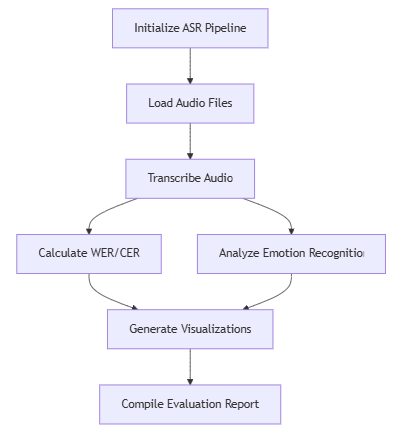

Step-by-Step Code Breakdown

Step 1: ASR Pipeline Initialization

    Configures wav2vec2 XLSR model with FP16 precision

    Enables GPU acceleration for optimal performance

    Implements 10-second chunk processing for long audio

Step 2: Emotion Recognition Setup

    Initializes DistilBERT emotion classifier

    Uses same GPU device as ASR for efficiency

Step 3: Audio Processing Loop

    Loads each audio file and converts to mono

    Measures transcription processing time

    Computes WER and CER against reference text

    Compares emotion labels between reference and ASR output

Step 4: Metric Aggregation

    Calculates average WER and CER across samples

    Computes emotion recognition accuracy percentage

    Determines Real-Time Factor (processing time vs audio duration)

Step 5: Visualization Suite

    Error Rate Comparison: Bar chart of average WER vs CER

    Emotion Accuracy: Pie chart of correct vs incorrect classifications

    WER Distribution: Histogram of error rates across samples

    Processing Efficiency: Scatter plot with real-time baseline

Step 6: Report Generation

    Creates structured text report with:

        Overall performance summary

        Sample-by-sample breakdown

        System configuration details

    Saves visualizations and report to disk

Connecting to the Lecture

    ASR Evaluation Fundamentals: Demonstrates core WER/CER metrics discussed in lecture

    Downstream Task Impact: Shows how ASR errors affect emotion recognition accuracy

    Efficiency Analysis: Real-Time Factor calculation addresses deployment constraints

    Model Selection: Uses modern wav2vec2 architecture for state-of-the-art performance

    Error Analysis: WER distribution visualization helps identify consistency issues

    Practical Implementation: Handles real-world challenges like stereo-to-mono conversion

    Holistic Assessment: Combines transcription accuracy with semantic task performance

    Reproducible Evaluation: Automated report generation supports benchmarking

    Hardware Optimization: Utilizes FP16 and GPU acceleration for efficient processing

In [1]:
!pip install jiwer transformers datasets

   ---------------------------------------- 0.0/25.8 MB ? eta -:--:--
   - -------------------------------------- 0.8/25.8 MB 5.6 MB/s eta 0:00:05
   -- ------------------------------------- 1.8/25.8 MB 4.4 MB/s eta 0:00:06
   --- ------------------------------------ 2.4/25.8 MB 3.5 MB/s eta 0:00:07
   ----- ---------------------------------- 3.4/25.8 MB 4.0 MB/s eta 0:00:06
   ------ --------------------------------- 4.2/25.8 MB 4.0 MB/s eta 0:00:06
   ------- -------------------------------- 5.0/25.8 MB 4.0 MB/s eta 0:00:06
   -------- ------------------------------- 5.5/25.8 MB 3.8 MB/s eta 0:00:06
   ---------- ----------------------------- 6.8/25.8 MB 4.0 MB/s eta 0:00:05
   ----------- ---------------------------- 7.6/25.8 MB 3.9 MB/s eta 0:00:05
   ------------- -------------------------- 8.4/25.8 MB 3.9 MB/s eta 0:00:05
   -------------- ------------------------- 9.2/25.8 MB 4.0 MB/s eta 0:00:05
   --------------- ------------------------ 10.0/25.8 MB 4.0 MB/s eta 0:00:04
   --

In [4]:
!pip install evaluate

Starting evaluation of 4 samples...


Could not load the `decoder` for jonatasgrosman/wav2vec2-large-xlsr-53-english. Defaulting to raw CTC. Error: No module named 'kenlm'
Try to install `kenlm`: `pip install kenlm
Try to install `pyctcdecode`: `pip install pyctcdecode
Device set to use cuda
Device set to use cuda
C:\Users\vinit_hqjv9wt\anaconda3\envs\SpeechLM\lib\site-packages\transformers\integrations\sdpa_attention.py:66: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at ..\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:455.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(



Sample 1/4:
  Reference: speech language models are transforming human computer interaction
  ASR Output: speech language models are transforming human computer interaction
  WER: 0.00% | CER: 0.00%
  True Emotion: joy | Predicted Emotion: joy

Sample 2/4:
  Reference: evaluation metrics like word error rate measure transcription accuracy
  ASR Output: evaluation matrixs like word erro rate measure transcription accuracy
  WER: 22.22% | CER: 4.29%
  True Emotion: joy | Predicted Emotion: joy

Sample 3/4:
  Reference: please call Stella ask her to bring these things with her from the store
  ASR Output: please call dela ask her to bring these things with her from the store
  WER: 7.14% | CER: 4.17%
  True Emotion: joy | Predicted Emotion: joy

Sample 4/4:
  Reference: convolutional neural networks and transformers form the basis of modern ASR systems
  ASR Output: convolutional neural networks and transformers formed the basis of modern asar systems
  WER: 16.67% | CER: 7.23%
  True Em

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



=== ASR EVALUATION REPORT ===

1. Performance Summary:
   - Samples Processed: 4
   - Average Word Error Rate (WER): 11.51%
   - Average Character Error Rate (CER): 3.92%
   - Emotion Recognition Accuracy: 100.00%
   - Average Real-Time Factor: 0.06 (1.0 = real-time)

2. Performance by Sample:

Sample 1: lecture_segment1.wav (10.0s)
  WER: 0.00% | CER: 0.00%
  Reference: speech language models are transforming human computer interaction
  ASR Output: speech language models are transforming human computer interaction
  True Emotion: joy | Predicted Emotion: joy
Sample 2: lecture_segment2.wav (10.0s)
  WER: 22.22% | CER: 4.29%
  Reference: evaluation metrics like word error rate measure transcription accuracy
  ASR Output: evaluation matrixs like word erro rate measure transcription accuracy
  True Emotion: joy | Predicted Emotion: joy
Sample 3: conversation1.wav (10.0s)
  WER: 7.14% | CER: 4.17%
  Reference: please call Stella ask her to bring these things with her from the store
  ASR

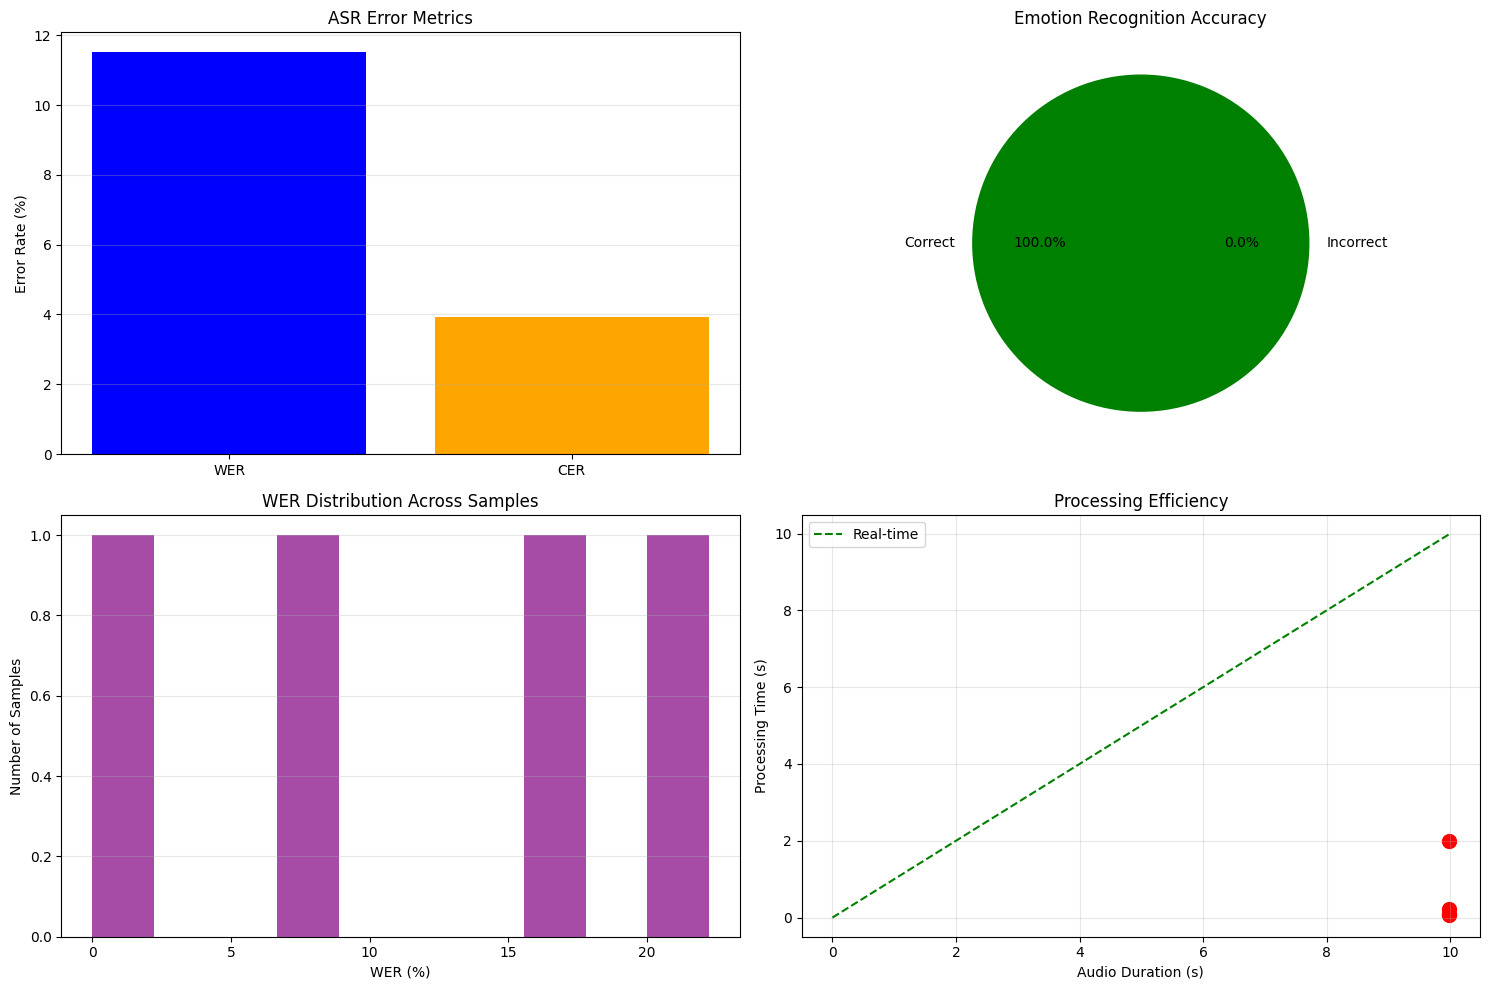

In [4]:
# Install: pip install jiwer transformers soundfile evaluate matplotlib numpy

import torch
import soundfile as sf
from transformers import pipeline
import evaluate
import numpy as np
import matplotlib.pyplot as plt
import os
import time

def evaluate_asr_system(audio_files, reference_texts):
    """
    Evaluate ASR system using local audio files and reference transcripts
    
    Args:
        audio_files: List of paths to audio files (e.g., ["sample1.wav", "sample2.wav"])
        reference_texts: List of reference transcripts in same order
    """
    # 1. Initialize ASR pipeline with FP16 optimization
    asr_pipe = pipeline(
        "automatic-speech-recognition",
        model="jonatasgrosman/wav2vec2-large-xlsr-53-english",  # SAFETENSORS weights
        device="cuda",
        torch_dtype=torch.float16,
        chunk_length_s=10  # Process long files in chunks
    )
    
    # 2. Initialize metrics
    wer_metric = evaluate.load("wer")
    cer_metric = evaluate.load("cer")
    
    # 3. Emotion recognition model (multi-class, safetensors)
    intent_clf = pipeline(
        "text-classification",
        model="bhadresh-savani/distilbert-base-uncased-emotion",
        device="cuda"
    )
    
    # 4. Run evaluation
    wer_scores, cer_scores, intent_acc = [], [], 0
    processing_times = []
    hypotheses = []
    
    for i, (audio_path, ref_text) in enumerate(zip(audio_files, reference_texts)):
        # Load audio
        audio_array, sample_rate = sf.read(audio_path)
        if len(audio_array.shape) > 1:
            # Convert to mono by averaging channels
            audio_array = np.mean(audio_array, axis=1)
        
        # ASR transcription with timing
        start_time = time.time()
        transcription = asr_pipe(
            {"raw": audio_array, "sampling_rate": sample_rate}
        )["text"]
        processing_times.append(time.time() - start_time)
        hypotheses.append(transcription)
        
        # WER/CER calculation
        wer_scores.append(wer_metric.compute(
            references=[ref_text], 
            predictions=[transcription]
        ))
        cer_scores.append(cer_metric.compute(
            references=[ref_text], 
            predictions=[transcription]
        ))
        
        # Emotion recognition accuracy
        true_emotion = intent_clf(ref_text)[0]["label"]
        pred_emotion = intent_clf(transcription)[0]["label"]
        intent_acc += 1 if true_emotion == pred_emotion else 0
        
        # Print sample result
        print(f"\nSample {i+1}/{len(audio_files)}:")
        print(f"  Reference: {ref_text}")
        print(f"  ASR Output: {transcription}")
        print(f"  WER: {wer_scores[-1]*100:.2f}% | CER: {cer_scores[-1]*100:.2f}%")
        print(f"  True Emotion: {true_emotion} | Predicted Emotion: {pred_emotion}")
    
    # 5. Calculate metrics
    avg_wer = np.mean(wer_scores)
    avg_cer = np.mean(cer_scores)
    intent_accuracy = intent_acc / len(audio_files)
    # Calculate durations for RTF
    durations = [len(sf.read(path)[0]) / sf.read(path)[1] for path in audio_files]
    avg_rtf = np.mean([t / d for t, d in zip(processing_times, durations)])
    
    # 6. Visualization
    plt.figure(figsize=(15, 10))
    
    # Error rates
    plt.subplot(2, 2, 1)
    plt.bar(["WER", "CER"], [avg_wer*100, avg_cer*100], color=['blue', 'orange'])
    plt.ylabel("Error Rate (%)")
    plt.title("ASR Error Metrics")
    plt.grid(axis='y', alpha=0.3)
    
    # Emotion accuracy
    plt.subplot(2, 2, 2)
    plt.pie([intent_accuracy, 1-intent_accuracy], 
            labels=["Correct", "Incorrect"],
            autopct='%1.1f%%',
            colors=['green', 'red'])
    plt.title("Emotion Recognition Accuracy")
    
    # WER distribution
    plt.subplot(2, 2, 3)
    plt.hist(np.array(wer_scores)*100, bins=10, color='purple', alpha=0.7)
    plt.xlabel("WER (%)")
    plt.ylabel("Number of Samples")
    plt.title("WER Distribution Across Samples")
    plt.grid(axis='y', alpha=0.3)
    
    # Processing time vs audio duration
    plt.subplot(2, 2, 4)
    plt.scatter(durations, processing_times, s=100, c='red')
    plt.plot([0, max(durations)], [0, max(durations)], 'g--', label="Real-time")
    plt.xlabel("Audio Duration (s)")
    plt.ylabel("Processing Time (s)")
    plt.title("Processing Efficiency")
    plt.legend()
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig("asr_evaluation_report.png", dpi=150)
    
    # 7. Generate comprehensive report
    report = f"""
=== ASR EVALUATION REPORT ===

1. Performance Summary:
   - Samples Processed: {len(audio_files)}
   - Average Word Error Rate (WER): {avg_wer*100:.2f}%
   - Average Character Error Rate (CER): {avg_cer*100:.2f}%
   - Emotion Recognition Accuracy: {intent_accuracy*100:.2f}%
   - Average Real-Time Factor: {avg_rtf:.2f} (1.0 = real-time)

2. Performance by Sample:
"""
    for i, (path, ref, hyp, wer, cer) in enumerate(zip(
        audio_files, reference_texts, hypotheses, wer_scores, cer_scores
    )):
        duration = len(sf.read(path)[0]) / sf.read(path)[1]
        true_emotion = intent_clf(ref)[0]["label"]
        pred_emotion = intent_clf(hyp)[0]["label"]
        report += f"\nSample {i+1}: {os.path.basename(path)} ({duration:.1f}s)"
        report += f"\n  WER: {wer*100:.2f}% | CER: {cer*100:.2f}%"
        report += f"\n  Reference: {ref}"
        report += f"\n  ASR Output: {hyp}"
        report += f"\n  True Emotion: {true_emotion} | Predicted Emotion: {pred_emotion}"

    report += f"\n\n3. System Information:"
    report += f"\n   - ASR Model: jonatasgrosman/wav2vec2-large-xlsr-53-english"
    report += f"\n   - Emotion Model: bhadresh-savani/distilbert-base-uncased-emotion"
    report += f"\n   - Processing Device: CUDA ({torch.cuda.get_device_name(0)})"
    report += f"\n   - Total Evaluation Time: {sum(processing_times):.1f} seconds"
    
    print(report)
    with open("asr_evaluation_report.txt", "w") as f:
        f.write(report)
    
    return {
        "wer": avg_wer,
        "cer": avg_cer,
        "emotion_accuracy": intent_accuracy,
        "rtf": avg_rtf,
        "hypotheses": hypotheses
    }

# Example usage with local files
if __name__ == "__main__":
    # Configuration - modify these to match your files
    AUDIO_DIR = r"C:\Users\vinit_hqjv9wt\Desktop\FinFree Project\Courses\Deep learning for Speech language model\6 Evaluation Metrics and Benchmarking of SpeechLMs\6.2 Evaluation of Different Capabilities"
    audio_files = [
        os.path.join(AUDIO_DIR, "lecture_segment1.wav"),
        os.path.join(AUDIO_DIR, "lecture_segment2.wav"),
        os.path.join(AUDIO_DIR, "conversation1.wav"),
        os.path.join(AUDIO_DIR, "technical_presentation.wav")
    ]
    
    reference_texts = [
        "speech language models are transforming human computer interaction",
        "evaluation metrics like word error rate measure transcription accuracy",
        "please call Stella ask her to bring these things with her from the store",
        "convolutional neural networks and transformers form the basis of modern ASR systems"
    ]
    
    # Verify file existence
    for path in audio_files:
        if not os.path.exists(path):
            print(f"Error: File not found - {path}")
            exit(1)
    
    print(f"Starting evaluation of {len(audio_files)} samples...")
    start_time = time.time()
    results = evaluate_asr_system(audio_files, reference_texts)
    print(f"\nEvaluation completed in {time.time()-start_time:.1f} seconds")
    print(f"Visualization saved to asr_evaluation_report.png")
    print(f"Detailed report saved to asr_evaluation_report.txt")